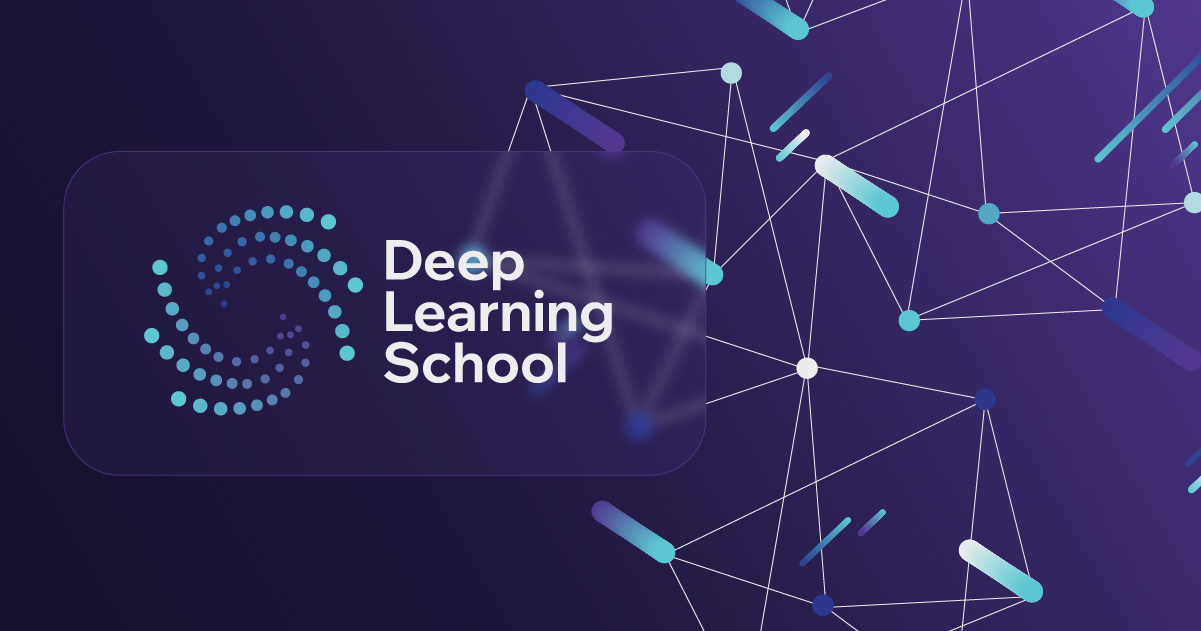

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Нейросетевая классификация текстов </b></h1>

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 KB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 KB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.9/132.9 KB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 KB 16.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.2/212.2 KB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.6/264.6 KB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 KB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 KB 11.5 MB/s eta 0:00:00


Импорт необходимых библиотек

In [12]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [6]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eplotnikov\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\eplotnikov\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части. 

In [4]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [7]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [8]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ] 
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])
    
    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [9]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [10]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])
    
    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна. 

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие. 

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно. 

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее. 
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству. 

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты. 
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет. 
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная? 
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

### Запуск базовой модели с семинара на новом датасете (1 балл)

Модель из семинара as-is:

In [17]:
class CharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 2,
        aggregation_type: str = 'max', p_dropout=0.1,
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=p_dropout)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

Семинарский Train вынесен в функцию

In [30]:
def train_model(model, train_dataloader, eval_dataloader, epochs=5, lr=1e-3, device='cuda'):
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    
    losses = []
    accs = []

    for epoch in tqdm(range(epochs)):
        model.train()
        total_loss = 0.0
        
        for batch in train_dataloader: # tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()
            
            inputs = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(inputs) 
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        model.eval() 
        acc = evaluate(model, eval_dataloader) 
        
        avg_loss = total_loss / len(train_dataloader)
        losses.append(avg_loss)
        accs.append(acc)
        print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f} | Eval Accuracy: {acc:.4f}")

    epochs_range = range(1, epochs + 1)

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, losses, label='Train Loss', color='red', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, accs, label='Eval Accuracy', color='blue', marker='o')
    plt.title('Evaluation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout() 
    plt.show()        


Обучение Baseline RNN:


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.4043 | Eval Accuracy: 0.8512
Epoch 2 | Train Loss: 0.2763 | Eval Accuracy: 0.8880
Epoch 3 | Train Loss: 0.2458 | Eval Accuracy: 0.8978
Epoch 4 | Train Loss: 0.2202 | Eval Accuracy: 0.9046
Epoch 5 | Train Loss: 0.2039 | Eval Accuracy: 0.9078


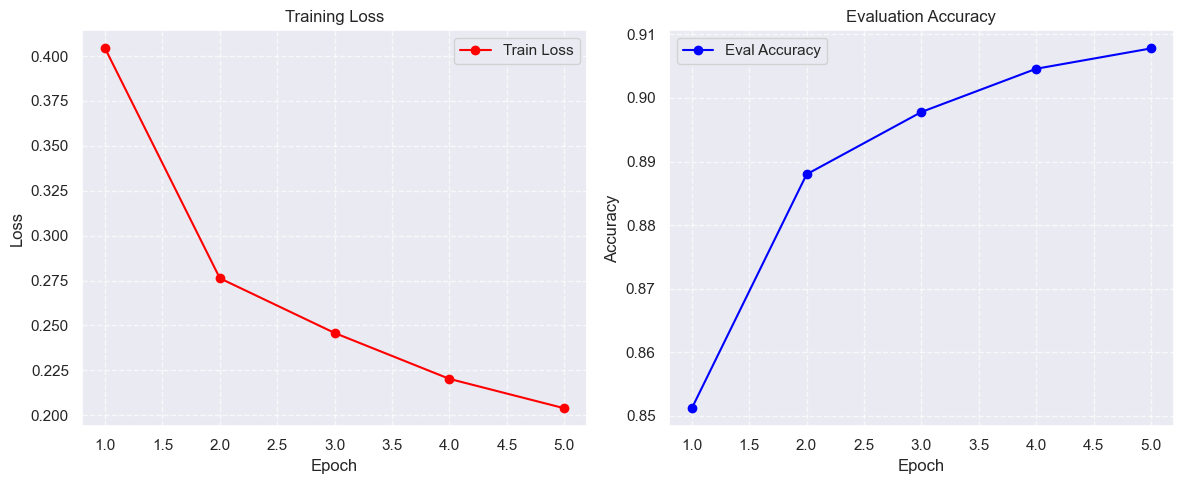

In [31]:
model_baseline = CharLM(hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_type='max').to(device)
print("Обучение Baseline RNN:")
train_model(model_baseline, train_dataloader, eval_dataloader, epochs=5)

Baseline семинарский дал 0.9 и не похоже чтобы мог выжать больше.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)

1. Сначала на дурачка поиграем с параметрами семинарского бэйзлайна. Я вынес вероятность dropout в параметры модели, пробую с dropout 0.5 и hidden dim 512.

Обучение Baseline RNN v2:


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.4930 | Eval Accuracy: 0.8776
Epoch 2 | Train Loss: 0.3556 | Eval Accuracy: 0.8822
Epoch 3 | Train Loss: 0.3244 | Eval Accuracy: 0.8882
Epoch 4 | Train Loss: 0.3051 | Eval Accuracy: 0.8938
Epoch 5 | Train Loss: 0.2854 | Eval Accuracy: 0.8894


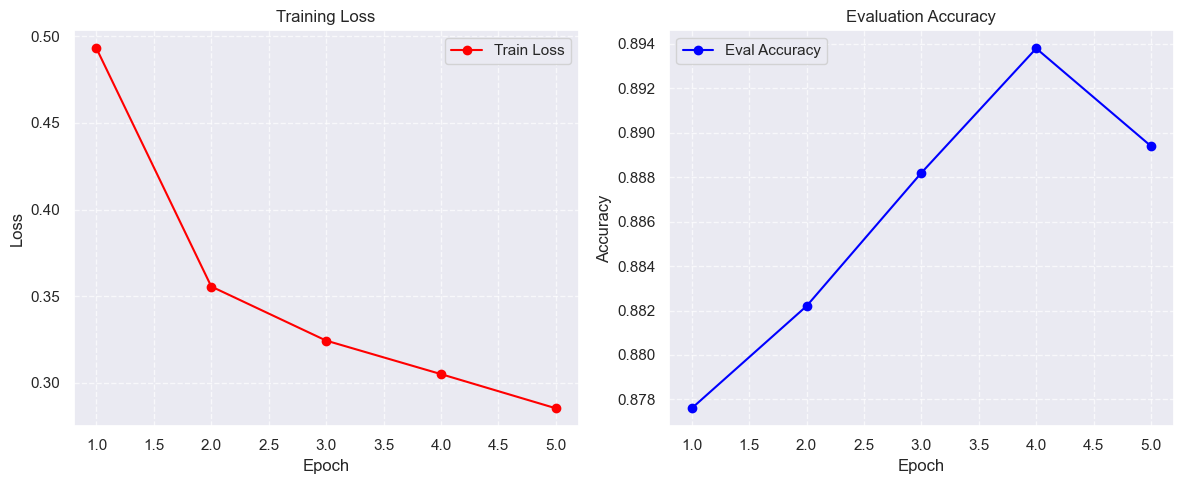

In [32]:
model_baseline_v2 = CharLM(hidden_dim=512, vocab_size=len(vocab), num_classes=4, aggregation_type='max', p_dropout=0.5).to(device)
print("Обучение Baseline RNN v2:")
train_model(model_baseline_v2, train_dataloader, eval_dataloader, epochs=5)

С простыми правками гиперпараметров accuracy не вырос.  
Почему бы не попробовать не только гиперпараметры поменять но и тип слоев на GRU:

In [33]:
class GRUModel(nn.Module):

    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4, aggregation_type: str = 'max', num_layers: int = 2, p_dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        
        # относительно семинарского бейзлайна RNN поменялся на GRU
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)

        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=p_dropout)
        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch) 
        output, _ = self.rnn(embeddings) 

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] 
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) 
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output))) 
        prediction = self.projection(self.non_lin(output)) 
        return prediction

Обучение GRU:


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.3603 | Eval Accuracy: 0.9128
Epoch 2 | Train Loss: 0.2242 | Eval Accuracy: 0.9162
Epoch 3 | Train Loss: 0.1718 | Eval Accuracy: 0.9172
Epoch 4 | Train Loss: 0.1351 | Eval Accuracy: 0.9098
Epoch 5 | Train Loss: 0.1099 | Eval Accuracy: 0.9132


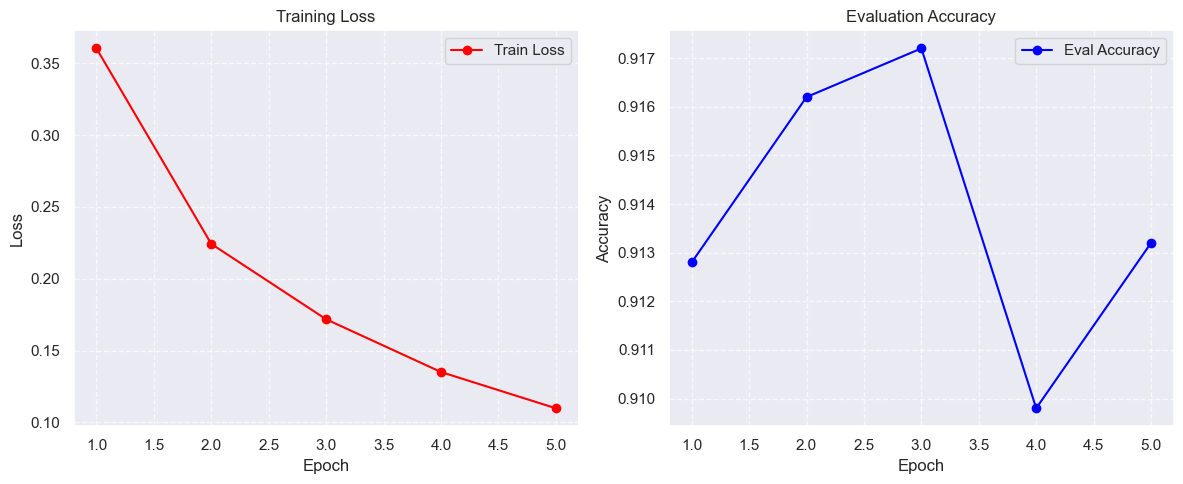

In [34]:
model_gru = GRUModel(hidden_dim=512, vocab_size=len(vocab), num_classes=4, aggregation_type='max', p_dropout=0.5).to(device)
print("Обучение GRU:")
train_model(model_gru, train_dataloader, eval_dataloader, epochs=5)

**0.9172 на 3й эпохе  дотягивает до макс. порога.**
Попробуем ещё более щадящий dropout 0.2:

Обучение GRU v2:


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.3467 | Eval Accuracy: 0.9082
Epoch 2 | Train Loss: 0.2151 | Eval Accuracy: 0.9106
Epoch 3 | Train Loss: 0.1613 | Eval Accuracy: 0.9120
Epoch 4 | Train Loss: 0.1219 | Eval Accuracy: 0.9118
Epoch 5 | Train Loss: 0.0987 | Eval Accuracy: 0.9108


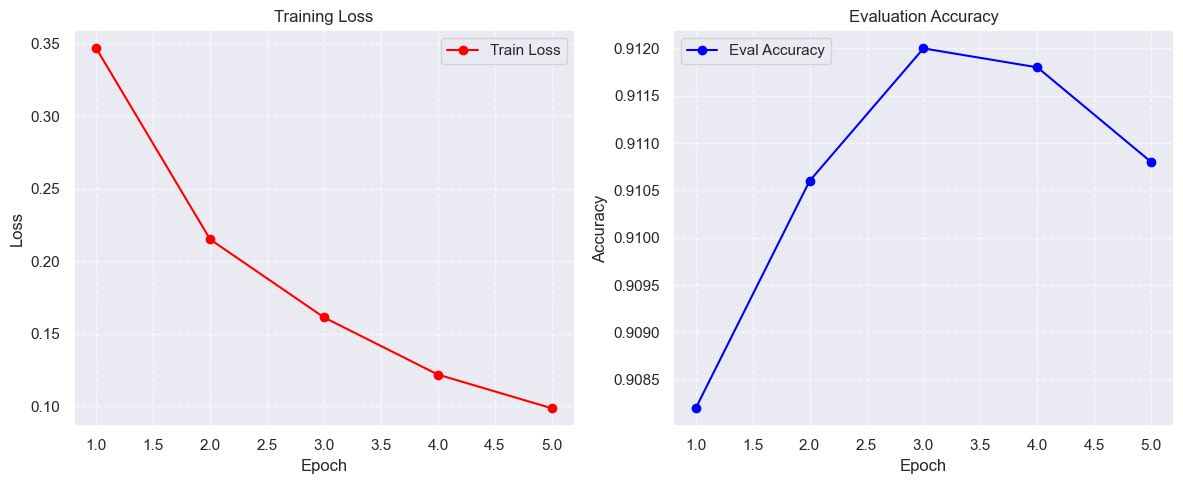

In [35]:
model_gru_v2 = GRUModel(hidden_dim=512, vocab_size=len(vocab), num_classes=4, aggregation_type='max', p_dropout=0.2).to(device)
print("Обучение GRU v2:")
train_model(model_gru_v2, train_dataloader, eval_dataloader, epochs=5)

Может, hidden dim = 512 это все же перебор и приводит к переобучению?  Попробуем 256 вернуть.

Обучение GRU v3:


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.3627 | Eval Accuracy: 0.8934
Epoch 2 | Train Loss: 0.2187 | Eval Accuracy: 0.9074
Epoch 3 | Train Loss: 0.1635 | Eval Accuracy: 0.9116
Epoch 4 | Train Loss: 0.1206 | Eval Accuracy: 0.9120
Epoch 5 | Train Loss: 0.0901 | Eval Accuracy: 0.9036


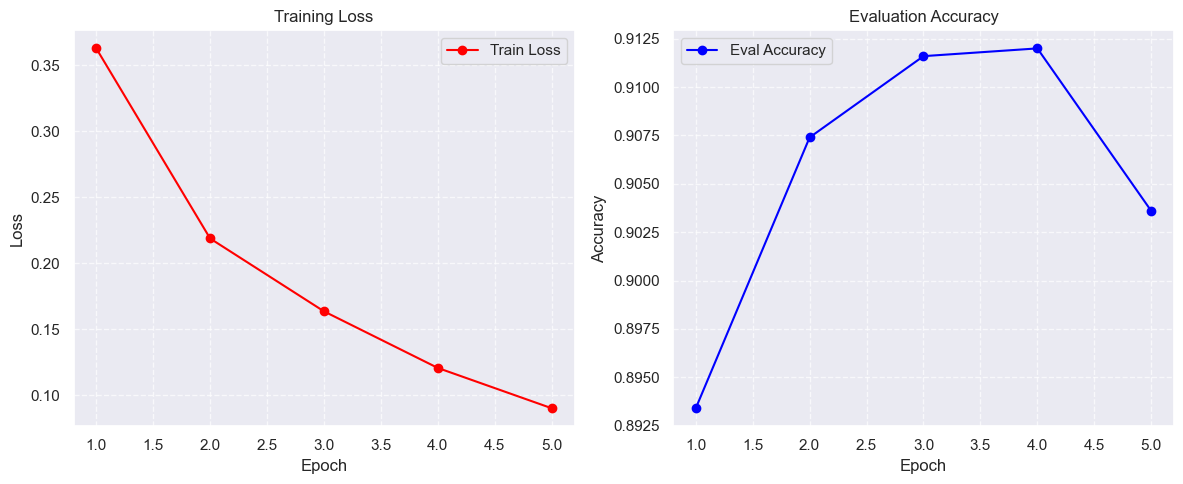

In [36]:
model_gru_v3 = GRUModel(hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_type='max', p_dropout=0.2).to(device)
print("Обучение GRU v3:")
train_model(model_gru_v3, train_dataloader, eval_dataloader, epochs=5)


  
Попробуем ещё GRU с большим кол-вом слоёв:

Обучение GRU v5:


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.3847 | Eval Accuracy: 0.9026
Epoch 2 | Train Loss: 0.2339 | Eval Accuracy: 0.9124
Epoch 3 | Train Loss: 0.1762 | Eval Accuracy: 0.9088
Epoch 4 | Train Loss: 0.1318 | Eval Accuracy: 0.8976
Epoch 5 | Train Loss: 0.1025 | Eval Accuracy: 0.9064


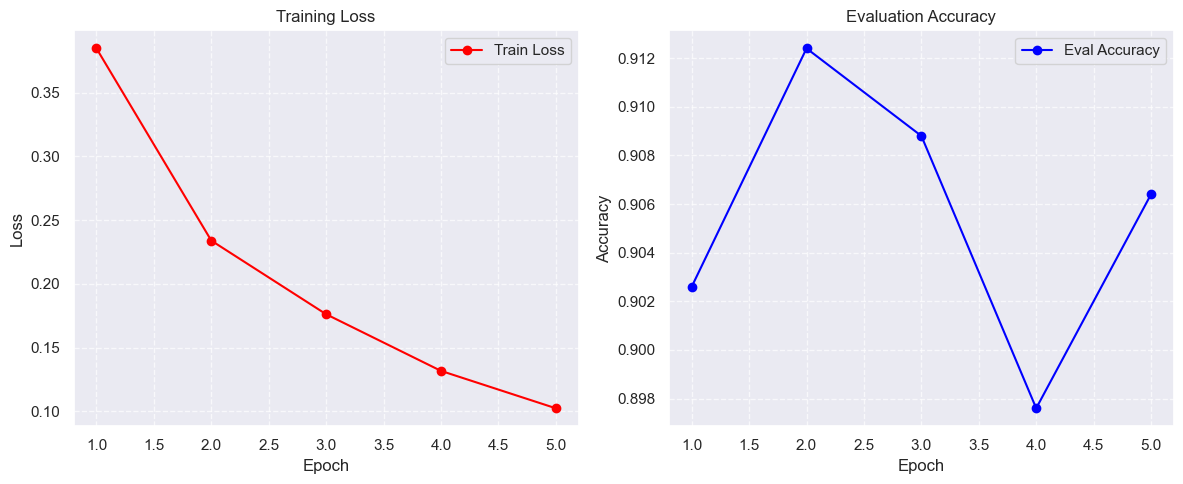

In [37]:
model_gru_v5 = GRUModel(hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_type='max', p_dropout=0.2, num_layers=3).to(device)
print("Обучение GRU v5:")
train_model(model_gru_v5, train_dataloader, eval_dataloader, epochs=5)

### Получение высокого качества (3 балла)

Лучшее качество получилось для модели `GRUModel` c `hidden_dim=512` и `p_dropout=0.5`:  
на 2й эпохе качество **0.9172**


### Оформление отчета (2 балла)

Что в итоге получилось:
- Базовая модель с семинара показала себя неплохо, но недостаточно для максимума (accuracy 0.9)
- тюнинг гиперпараметров RNN ничего особо не дал

- переход на GRU сразу дал нужный результат: 0.9172

Остальные попытки (уменьшение дропаута, изменение hidden_dim, добавление слоев) не дали прироста

По графикам обучения можно сказать, что все варианты моделей достигают пика по score на ранних эпохах и далее особо не растут. GRU версии даже раньше обучаются до максимального качества и далее идут на спад (train loss падает, overfitting рушит скор). GRU ведёт себя получше, что неудивительно, т.к решает проблему с забыванием контекста из прошлого. От этого же и быстрее переобучается. Dropout сдерживает переобучение, для этого его выкручивал сильно больше стартового 0.1.

Лучшее качество получилось для модели `GRUModel` c `hidden_dim=512` и `p_dropout=0.5`:  
на 2й эпохе качество **0.9172**

